# Stored restriction maps visualisations

## 1. Imports

In [321]:
import torch

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import networkx as nx

#Texas
maps = torch.load("/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/maps/DiagSheaf_texas_fold0_seed43_20260317_151001.pt")

print(type(maps))

<class 'torch.Tensor'>


## 2. Inspection

In [322]:
print(type(maps))
print(len(maps) if hasattr(maps, '__len__') else "Not iterable")

# If it's a tensor
if isinstance(maps, torch.Tensor):
    print(maps.shape)

# If it's a list or dict
if isinstance(maps, (list, tuple)):
    print(type(maps[0]), maps[0].shape)

if isinstance(maps, dict):
    print(maps.keys())

print(maps[:10])

<class 'torch.Tensor'>
558
torch.Size([558, 3])
tensor([[  0.0000,  58.0000,  -0.7995],
        [  0.0000, 121.0000,  -0.8021],
        [  1.0000,  80.0000,  -0.8003],
        [  2.0000,   8.0000,  -0.7882],
        [  3.0000,  56.0000,  -0.8265],
        [  4.0000,  66.0000,  -0.8247],
        [  4.0000, 146.0000,  -0.8303],
        [  4.0000, 164.0000,  -0.8287],
        [  5.0000,  20.0000,  -0.8099],
        [  5.0000,  56.0000,  -0.8101]])


## 3. Boundary Map

In [323]:
print(maps)

tensor([[  0.0000,  58.0000,  -0.7995],
        [  0.0000, 121.0000,  -0.8021],
        [  1.0000,  80.0000,  -0.8003],
        ...,
        [177.0000, 156.0000,  -0.8131],
        [177.0000, 167.0000,  -0.8057],
        [175.0000, 173.0000,  -0.7880]])


In [324]:
df = pd.DataFrame(maps.cpu().tolist(),columns=["source", "target", "map_value"])

df[["source", "target"]] = df[["source", "target"]].astype(int)
df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
df

,source,target,map_value
0,0,58,-0.799491
1,0,121,-0.802126
2,1,80,-0.800296
3,2,8,-0.788248
4,3,56,-0.826531
...,...,...,...
385,180,47,-0.795254
497,180,66,-0.799385
518,180,84,-0.814694
470,181,56,-0.813857


In [325]:
df_low = df[df["source"] <= df["target"]]
display(df_low)

df_high = df[df["source"] >= df["target"]]
display(df_high)

,source,target,map_value
0,0,58,-0.799491
1,0,121,-0.802126
2,1,80,-0.800296
3,2,8,-0.788248
4,3,56,-0.826531
...,...,...,...
274,150,159,-0.796661
275,151,152,-0.804379
276,156,177,-0.800837
277,167,177,-0.803693


,source,target,map_value
282,8,2,-0.802070
292,14,7,-0.823553
303,16,15,-0.791238
287,20,5,-0.802978
304,20,15,-0.808484
...,...,...,...
385,180,47,-0.795254
497,180,66,-0.799385
518,180,84,-0.814694
470,181,56,-0.813857


In [326]:
df = df.copy()
df[["source", "target"]] = df[["source", "target"]].astype(int)

# signed value
df["signed_map"] = np.where(
    df["target"] < df["source"],
    df["map_value"],
    -df["map_value"]
)

# canonical undirected edge label
df["edge"] = df.apply(
    lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),
    axis=1
)

# build node-by-edge matrix
nodes = sorted(set(df["source"]).union(df["target"]))
edges = sorted(df["edge"].unique())

B = df.pivot(index="source", columns="edge", values="signed_map")
B = B.reindex(index=nodes, columns=edges, fill_value=0)

B.fillna(0, inplace=True)

In [327]:
B

edge,"(0.0, 58.0)","(0.0, 121.0)","(1.0, 80.0)","(2.0, 8.0)","(3.0, 56.0)","(4.0, 66.0)","(4.0, 146.0)","(4.0, 164.0)","(5.0, 20.0)","(5.0, 56.0)",...,"(145.0, 168.0)","(145.0, 173.0)","(146.0, 148.0)","(146.0, 164.0)","(148.0, 159.0)","(150.0, 159.0)","(151.0, 152.0)","(156.0, 177.0)","(167.0, 177.0)","(173.0, 175.0)"
source,,,,,,,,,,,,,,,,,,,,,
0,0.799491,0.802126,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.800296,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.788248,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.826531,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.824675,0.830257,0.828721,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
180,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [328]:
((B != 0).sum(axis=0)).value_counts()

2    279
Name: count, dtype: int64

In [329]:
B_np = B.to_numpy(dtype=float)
B_np.shape

(183, 279)

## 4. Laplacian & Visual

In [330]:
L0 = B_np @ B_np.T
L0

array([[1.28259252, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.64047437, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.62133567, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.93517149, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.66236354,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.64181701]])

In [331]:
L1 = B_np.T @ B_np
np.all(L1 == L1.T)

np.True_

In [332]:
#Curvature
# F, w/ F[i,j] = L1

In [333]:
# Forman Bochner Decomposition
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
#B=B.astype(int)
    F=L-B
    return B , F

B1, F1 = fbc(L1)
B1

array([[5.07128282, 0.64129279, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.64129279, 0.64129279, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 2.56359961, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.91014561, 0.65508276,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.65508276, 3.18255057,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        3.84159608]])

In [334]:
F1

array([[-3.79371194,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.64768619,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -1.28472906, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.60767251,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -1.88754086,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -2.57739724]])

In [335]:
edge_list = list(B.columns)
print(edge_list)

[(np.float64(0.0), np.float64(58.0)), (np.float64(0.0), np.float64(121.0)), (np.float64(1.0), np.float64(80.0)), (np.float64(2.0), np.float64(8.0)), (np.float64(3.0), np.float64(56.0)), (np.float64(4.0), np.float64(66.0)), (np.float64(4.0), np.float64(146.0)), (np.float64(4.0), np.float64(164.0)), (np.float64(5.0), np.float64(20.0)), (np.float64(5.0), np.float64(56.0)), (np.float64(5.0), np.float64(101.0)), (np.float64(6.0), np.float64(56.0)), (np.float64(6.0), np.float64(171.0)), (np.float64(7.0), np.float64(14.0)), (np.float64(7.0), np.float64(34.0)), (np.float64(8.0), np.float64(173.0)), (np.float64(9.0), np.float64(56.0)), (np.float64(9.0), np.float64(106.0)), (np.float64(10.0), np.float64(108.0)), (np.float64(11.0), np.float64(56.0)), (np.float64(11.0), np.float64(94.0)), (np.float64(11.0), np.float64(108.0)), (np.float64(12.0), np.float64(56.0)), (np.float64(13.0), np.float64(58.0)), (np.float64(15.0), np.float64(16.0)), (np.float64(15.0), np.float64(20.0)), (np.float64(15.0), np

In [336]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

array([-3.79371194e+00,  6.47686195e-01, -1.28472906e+00,  6.19697603e-01,
       -6.53808438e+01, -7.68988382e+00, -4.59570008e+00, -6.83317455e-01,
       -1.93807945e+00, -6.53846407e+01, -1.28831994e-02, -6.59702036e+01,
       -3.19096724e+00,  6.80169287e-01, -3.15466714e+00, -3.20749091e+00,
       -6.73320539e+01,  6.74109072e-01, -1.34779760e+00, -6.73168874e+01,
       -1.28494151e+00, -2.61468910e+00, -6.44494480e+01, -3.11609202e+00,
       -8.48280512e+00, -5.26417870e+00, -5.34024216e+00, -7.84460100e+00,
       -4.66107099e+00, -3.35806807e+00, -4.67832637e+00, -3.37455042e+00,
       -5.90778702e+00, -7.14124403e+01, -5.14113557e+00, -5.19701946e+00,
       -5.17382605e+00, -3.84801076e+00, -5.15385572e+00, -5.79951345e+00,
       -2.59559102e+00, -6.55725384e+01, -6.40721366e-01, -9.65356831e-03,
       -6.57409265e+01, -6.30721749e-01, -6.56810829e-01, -6.52987060e+01,
       -1.31132593e+00, -6.61500750e+01, -5.10114675e+00, -1.93438564e+00,
       -6.65034791e+01, -

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_60547/3886179207.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


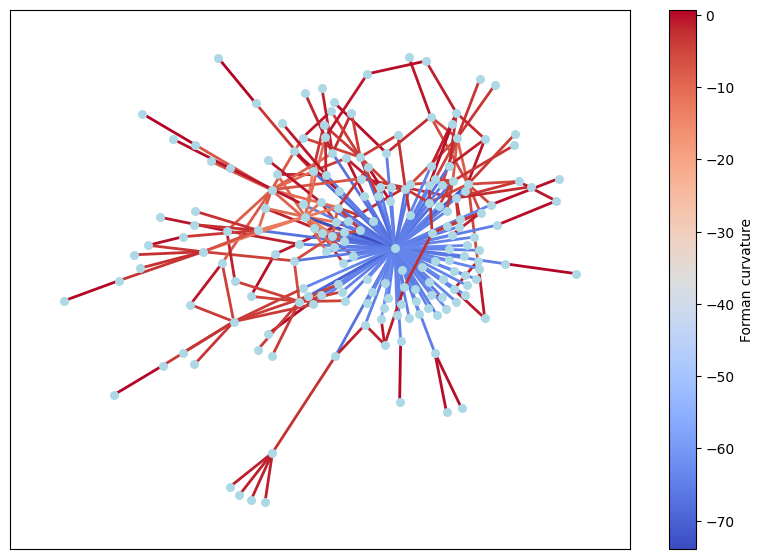

In [337]:
pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax, label='Forman curvature')
f.show()

In [338]:
B0, F0 = fbc(L0)

In [339]:
display(L0)

array([[1.28259252, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.64047437, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.62133567, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.93517149, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.66236354,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.64181701]])

In [340]:
display(F0)
display(B0)

array([[-0.00068138,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.00103994,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.01089467, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.00412277,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.01356136,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.0029996 ]])

array([[1.28327389, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.63943443, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.63223033, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.93929426, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.64880218,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.6448166 ]])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

array([[1., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_60547/2956166109.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


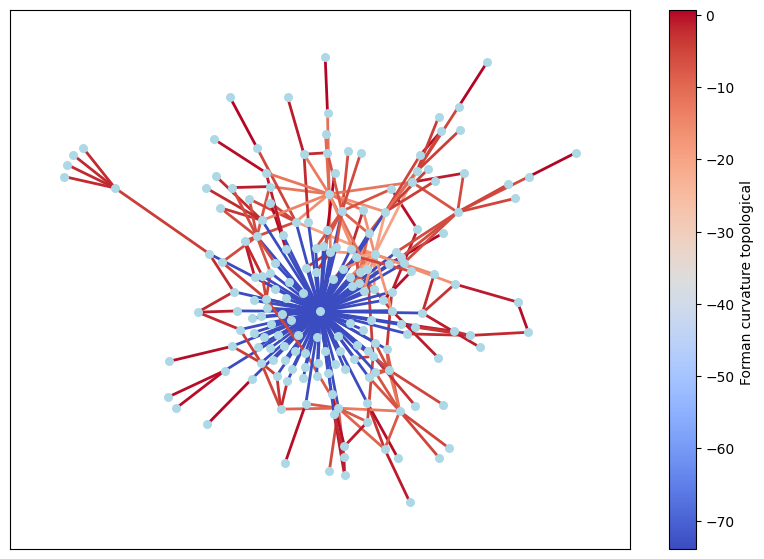

In [ ]:
B_top = nx.incidence_matrix(G).todense()
L0_top = B_top @ B_top.T
L1_top = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top = np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm1_top = plt.Normalize(vmin=f1.min(), vmax=f1.max())
nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1_top(f1_top)),pos = pos, width=2)
sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
plt.colorbar(sm1, ax=ax, label='Forman curvature topological ')

### Forman Curvature: Sheaf vs Topological

array([-3.79371194e+00,  6.47686195e-01, -1.28472906e+00,  6.19697603e-01,
       -6.53808438e+01, -7.68988382e+00, -4.59570008e+00, -6.83317455e-01,
       -1.93807945e+00, -6.53846407e+01, -1.28831994e-02, -6.59702036e+01,
       -3.19096724e+00,  6.80169287e-01, -3.15466714e+00, -3.20749091e+00,
       -6.73320539e+01,  6.74109072e-01, -1.34779760e+00, -6.73168874e+01,
       -1.28494151e+00, -2.61468910e+00, -6.44494480e+01, -3.11609202e+00,
       -8.48280512e+00, -5.26417870e+00, -5.34024216e+00, -7.84460100e+00,
       -4.66107099e+00, -3.35806807e+00, -4.67832637e+00, -3.37455042e+00,
       -5.90778702e+00, -7.14124403e+01, -5.14113557e+00, -5.19701946e+00,
       -5.17382605e+00, -3.84801076e+00, -5.15385572e+00, -5.79951345e+00,
       -2.59559102e+00, -6.55725384e+01, -6.40721366e-01, -9.65356831e-03,
       -6.57409265e+01, -6.30721749e-01, -6.56810829e-01, -6.52987060e+01,
       -1.31132593e+00, -6.61500750e+01, -5.10114675e+00, -1.93438564e+00,
       -6.65034791e+01, -

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

array([[1., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

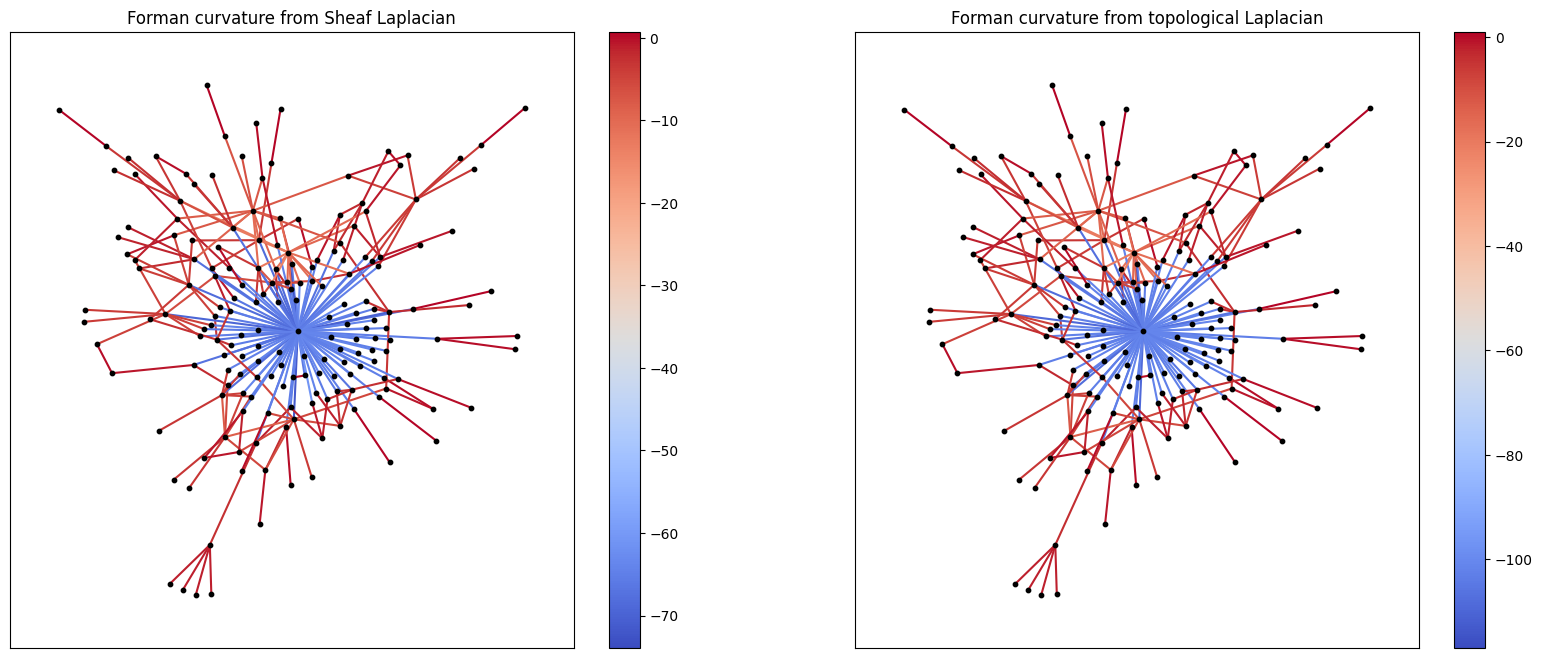

In [342]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

# pos = nx.spring_layout(G)
# f,ax = plt.subplots(1,1,figsize=(10,7))
# nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
# #nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
# cmap = plt.cm.coolwarm
# norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
# nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
# plt.colorbar(sm1, ax=ax, label='Forman curvature')

B_top = nx.incidence_matrix(G).todense()
L0_top = B_top @ B_top.T
L1_top = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top = np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

# pos = nx.spring_layout(G)
# f,ax = plt.subplots(1,1,figsize=(10,7))
# nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
# #nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
# cmap = plt.cm.coolwarm
# norm1_top = plt.Normalize(vmin=f1.min(), vmax=f1.max())
# nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1_top(f1_top)),pos = pos, width=2)
# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
# plt.colorbar(sm1, ax=ax, label='Forman curvature topological ')
# f.show()

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,2,figsize=(20,8))
cmap = plt.cm.coolwarm

nx.draw_networkx_nodes(G, ax=ax[0], node_color='k', pos = pos, node_size=10)
nx.draw_networkx_nodes(G, ax=ax[1], node_color='k', pos = pos, node_size=10)

norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
norm1_top = plt.Normalize(vmin=f1_top.min(), vmax=f1_top.max())

nx.draw_networkx_edges(G,ax =ax[0], edge_color = cmap(norm1(f1)),pos = pos, width=1.5)
nx.draw_networkx_edges(G,ax =ax[1], edge_color = cmap(norm1_top(f1_top)),pos = pos, width=1.5)

sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax[0])
sm1_top = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
plt.colorbar(sm1_top, ax=ax[1])

ax[0].set_title("Forman curvature from Sheaf Laplacian")
ax[1].set_title("Forman curvature from topological Laplacian")
plt.show()

In [343]:
np.all(f1 == f1_top)

np.False_

In [344]:
G= nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)

array([-6.81377608e-04,  1.03993788e-03, -1.08946687e-02,  1.21695566e-02,
        5.77893309e-02,  1.57320367e-02,  3.46510037e-03, -2.19954240e-02,
        9.07585174e-03, -4.84013494e-02, -2.05704573e-02, -3.19396936e-02,
        5.55224027e-03,  1.28521203e-02,  3.04272791e-02,  9.42118061e-02,
       -3.76046568e-02, -1.48680236e-02, -1.37472057e-02, -3.53027596e-03,
       -3.04265233e-02,  1.50357511e-02,  3.68679652e-03, -1.52402462e-02,
       -1.39309506e-02,  2.27128532e-02,  1.25769759e-02,  4.78591681e-03,
       -3.86884081e-02,  1.77393868e-02, -5.39155745e-02, -2.29813645e-02,
        2.81262754e-03, -8.97504752e-03,  2.43398364e-02, -2.85615749e-03,
       -1.96511270e-02,  2.53962550e-02,  4.38255530e-03, -5.49234790e-03,
        4.91796765e-03, -2.47974759e-03, -1.23919902e-02, -2.37794872e-03,
       -5.99218212e-03, -7.28033122e-03,  7.98121467e-03,  7.32003151e-02,
        2.37689724e-02,  5.22973045e-04, -8.12151787e-03,  2.12920027e-03,
       -3.31046263e-02, -

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_60547/4084525455.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


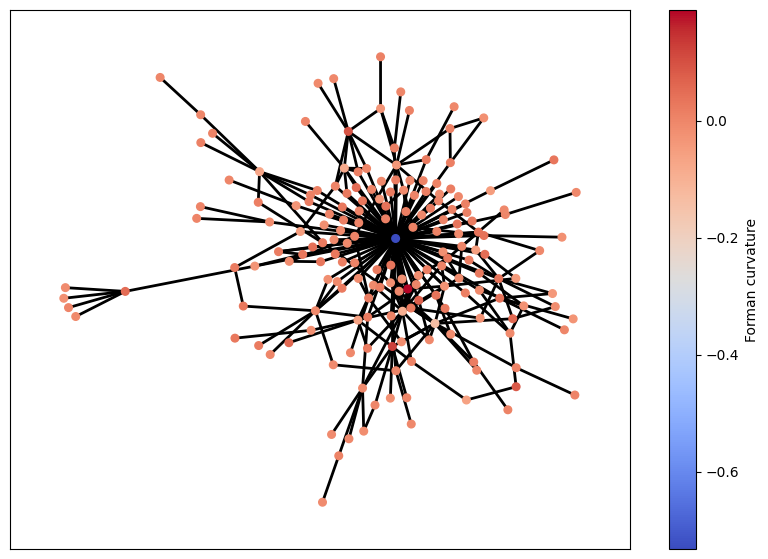

In [345]:
# G.relabel_nodes({i: node for i, node in enumerate(nodes)}, copy=False)
f0 = np.diag(F0)
display(f0)

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm0 = plt.Normalize(vmin=f0.min(), vmax=f0.max())
nx.draw_networkx_nodes(G, ax=ax, node_color=cmap(norm0(f0)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax,pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
plt.colorbar(sm0, ax=ax, label='Forman curvature')
f.show()

In [346]:
G.nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182))

## 5. Plot Classes 

In [347]:
with open("/Users/luigifracassetti/projects/neural-sheaf-diffusion/datasets/texas/raw/out1_node_feature_label.txt", "r") as f:
    for line in f:
        print(line.strip())
    df_node_feature = pd.read_csv("/Users/luigifracassetti/projects/neural-sheaf-diffusion/datasets/texas/raw/out1_node_feature_label.txt", sep="\t")

node_id	feature	label
0	0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [348]:
df_node_feature

,node_id,feature,label
0,0,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",3
1,1,"0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,...",0
2,2,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",2
3,3,"0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",3
4,4,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",4
...,...,...,...
178,178,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",3
179,179,"0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,...",3
180,180,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",4
181,181,"0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,...",3


In [349]:
lab = df_node_feature["label"].values
lab

array([3, 0, 2, 3, 4, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 4, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 1, 3, 3, 0, 2, 3, 3, 4, 3, 4, 4, 2, 3, 3, 3, 0, 4, 0, 3,
       3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 0, 2, 2, 4, 4, 4, 3, 3, 3, 3,
       0, 3, 3, 3, 4, 3, 3, 4, 4, 3, 0, 3, 0, 3, 4, 3, 2, 4, 2, 4, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 4, 3, 3, 3, 4, 0, 0, 4, 3, 3, 0, 4, 3, 2, 3,
       3, 0, 3, 0, 0, 3, 3, 4, 3, 3, 3, 0, 3, 0, 3, 2, 4, 2, 3, 3, 0, 4,
       3, 4, 3, 4, 3, 3, 0, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3,
       3, 3, 0, 2, 0, 2, 3, 3, 4, 3, 0, 3, 3, 2, 0, 3, 3, 4, 3, 2, 0, 3,
       0, 4, 3, 3, 4, 3, 3])

In [350]:
G.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182))

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_60547/1984811150.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


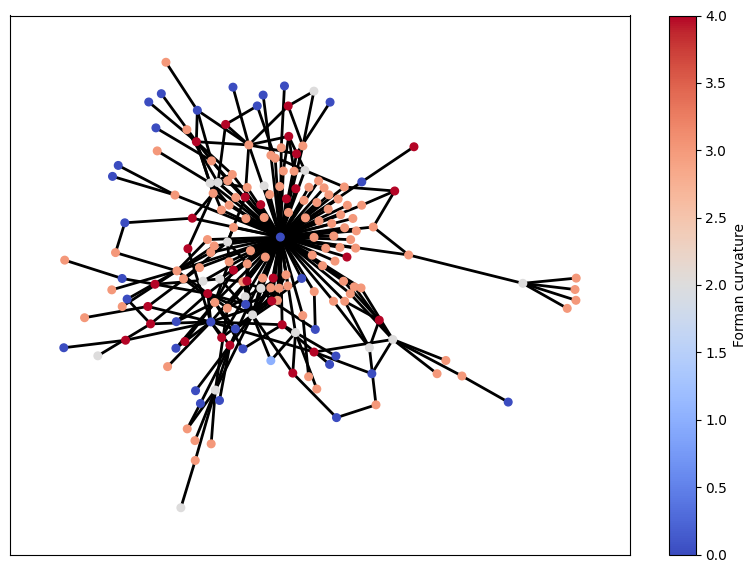

In [351]:
pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm0 = plt.Normalize(vmin=lab.min(), vmax=lab.max())
nx.draw_networkx_nodes(G, ax=ax, node_color=cmap(norm0(lab)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax,pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
plt.colorbar(sm0, ax=ax, label='Forman curvature')
f.show()

array([3, 0, 2, 3, 4, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 4, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 1, 3, 3, 0, 2, 3, 3, 4, 3, 4, 4, 2, 3, 3, 3, 0, 4, 0, 3,
       3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 0, 2, 2, 4, 4, 4, 3, 3, 3, 3,
       0, 3, 3, 3, 4, 3, 3, 4, 4, 3, 0, 3, 0, 3, 4, 3, 2, 4, 2, 4, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 4, 3, 3, 3, 4, 0, 0, 4, 3, 3, 0, 4, 3, 2, 3,
       3, 0, 3, 0, 0, 3, 3, 4, 3, 3, 3, 0, 3, 0, 3, 2, 4, 2, 3, 3, 0, 4,
       3, 4, 3, 4, 3, 3, 0, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3,
       3, 3, 0, 2, 0, 2, 3, 3, 4, 3, 0, 3, 3, 2, 0, 3, 3, 4, 3, 2, 0, 3,
       0, 4, 3, 3, 4, 3, 3])

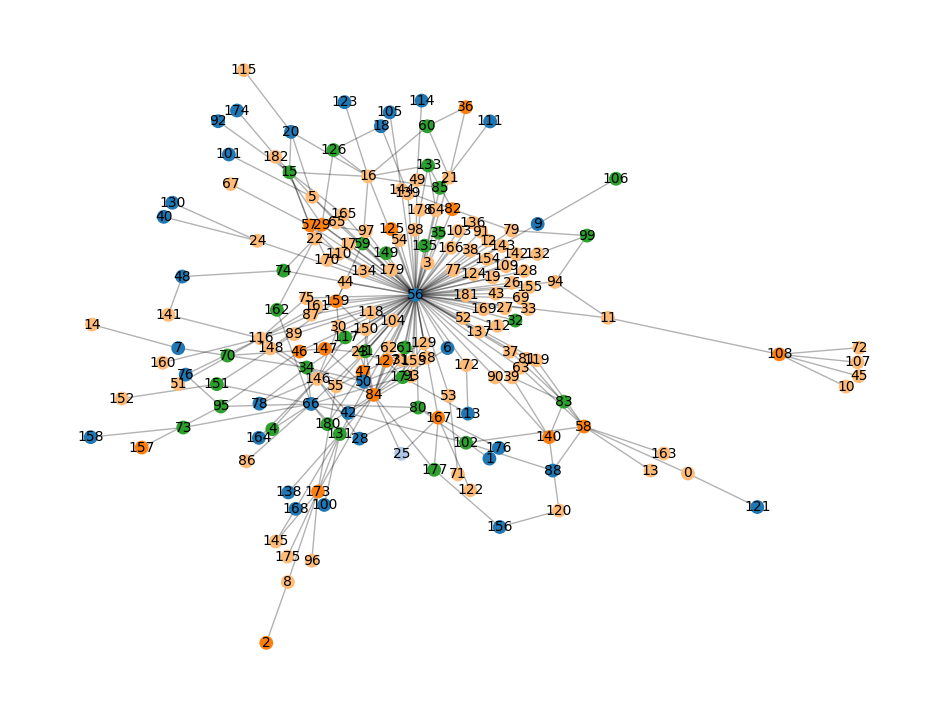

In [352]:
lab = df_node_feature["label"].values
display(lab)

# Plot graph nodes colored by `lab` (handles one-hot or integer labels). Uses existing `G` and `pos` if present.
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

labels = lab
if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

unique = np.unique(labels)

cmap = plt.get_cmap('tab20')
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap(label_to_idx[int(labels[n]) % 20]) for n in sorted(G.nodes())]

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)

plt.figure(figsize=(12, 9))
nx.draw_networkx_nodes(G, pos_use, node_color=node_colors, node_size=80)
nx.draw_networkx_edges(G, pos_use, alpha=0.3)
nx.draw_networkx_labels(G, pos=pos_use, font_size=10)
plt.axis('off')
plt.show()

In [353]:
neigh_56_edges =[_ for _  in list(G.edges()) if 56 in _]
# display(neigh_56_edges)

neigh_56_nodes = [int(j) if i == 56 else int(i) for (i, j) in neigh_56_edges]
# display(neigh_56_nodes)

#associating neighborhing nodes to their labels
neigh_56_labels = {n: int(lab[n]) for n in neigh_56_nodes}
# display(neigh_56_labels)

similar_class_ratio = sum(1 for n in neigh_56_nodes if lab[n] == lab[56]) / len(neigh_56_nodes)
similar_class_ratio

0.019230769230769232

### 5.1 Sheaf Forman Curvature & Classes

array([3, 0, 2, 3, 4, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 4, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 1, 3, 3, 0, 2, 3, 3, 4, 3, 4, 4, 2, 3, 3, 3, 0, 4, 0, 3,
       3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 0, 2, 2, 4, 4, 4, 3, 3, 3, 3,
       0, 3, 3, 3, 4, 3, 3, 4, 4, 3, 0, 3, 0, 3, 4, 3, 2, 4, 2, 4, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 4, 3, 3, 3, 4, 0, 0, 4, 3, 3, 0, 4, 3, 2, 3,
       3, 0, 3, 0, 0, 3, 3, 4, 3, 3, 3, 0, 3, 0, 3, 2, 4, 2, 3, 3, 0, 4,
       3, 4, 3, 4, 3, 3, 0, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3,
       3, 3, 0, 2, 0, 2, 3, 3, 4, 3, 0, 3, 3, 2, 0, 3, 3, 4, 3, 2, 0, 3,
       0, 4, 3, 3, 4, 3, 3])

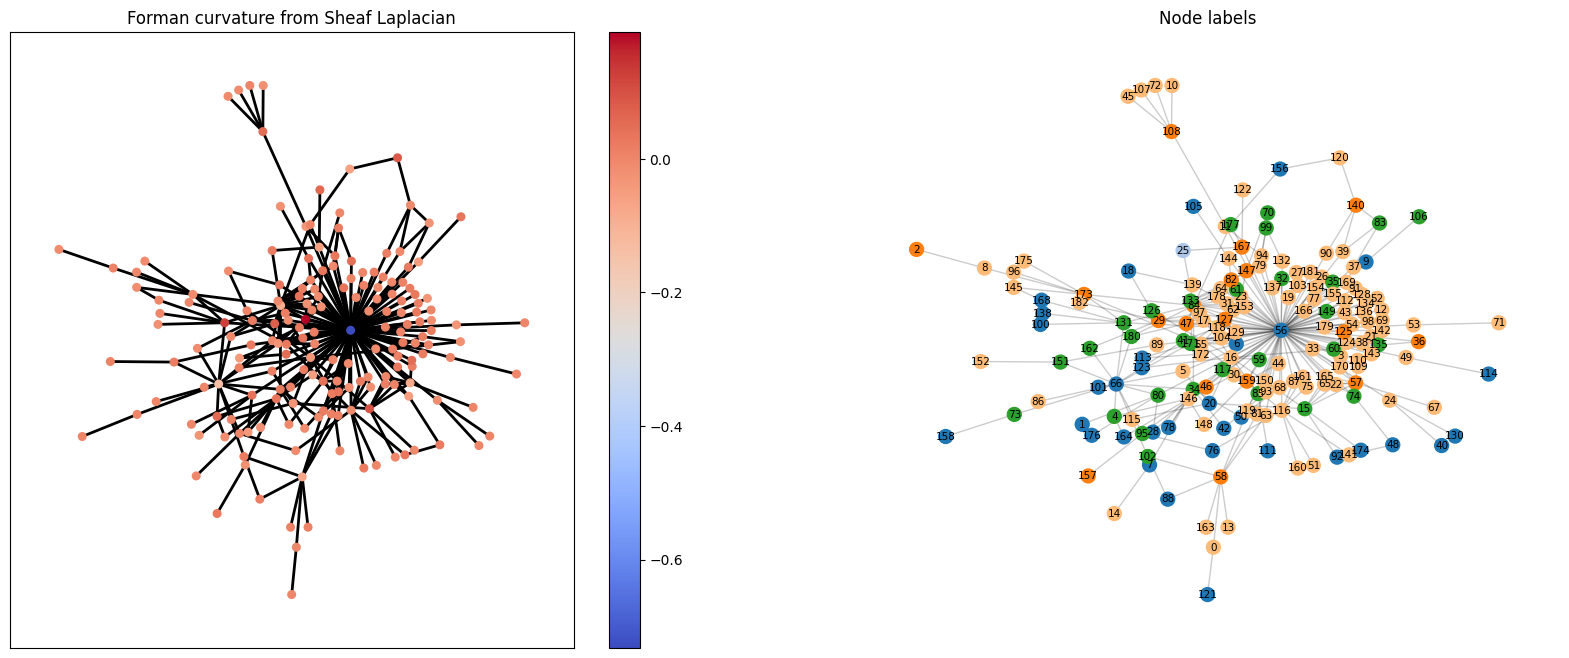

In [ ]:
pos = nx.spring_layout(G)
lab = df_node_feature["label"].values
display(lab)

# Plot graph nodes colored by `lab` (handles one-hot or integer labels). Uses existing `G` and `pos` if present.
f,ax = plt.subplots(1,2,figsize=(20,8))
cmap = plt.cm.coolwarm

norm0 = plt.Normalize(vmin=f0.min(), vmax=f0.max())
nx.draw_networkx_nodes(G, ax=ax[0], node_color=cmap(norm0(f0)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax[0],pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
ax[0].set_title("Forman curvature from Sheaf Laplacian")
plt.colorbar(sm0, ax=ax[0])

if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap('tab20')
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n]) % 20]) for n in sorted(G.nodes())]

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, ax=ax[1], node_color=node_colors, node_size=100, pos=pos_use)
nx.draw_networkx_edges(G, ax=ax[1], pos=pos_use, alpha=0.2)
nx.draw_networkx_labels(G, ax=ax[1], pos=pos_use, font_size=7.5)
ax[1].set_title("Node labels")
plt.axis('off')

plt.show()

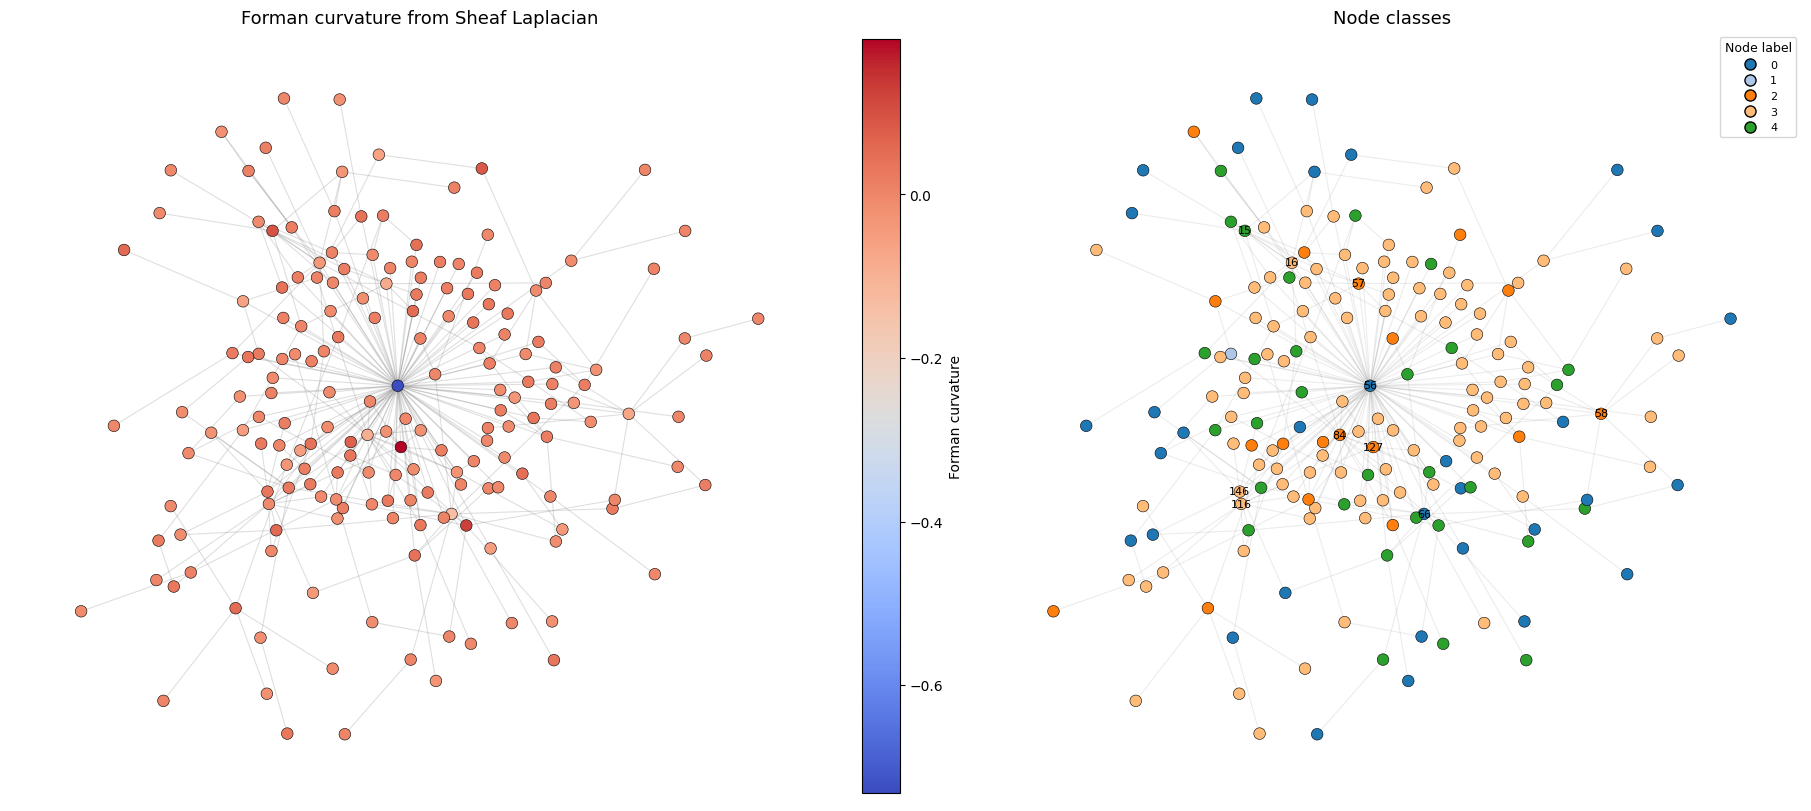

In [355]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# Stable layout
pos = nx.spring_layout(G, seed=42, k=0.25)

labels = df_node_feature["label"].values
if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

# Make sure node ordering matches graph nodes
nodes_sorted = sorted(G.nodes())
labels_sorted = np.array([labels[n] for n in nodes_sorted])
f0_sorted = np.array([f0[n] for n in nodes_sorted])

fig, ax = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# ------------------------
# Panel 1: curvature plot
# ------------------------
cmap_curv = plt.cm.coolwarm
norm_curv = Normalize(vmin=f0_sorted.min(), vmax=f0_sorted.max())

nx.draw_networkx_edges(
    G,
    pos=pos,
    ax=ax[0],
    width=0.8,
    alpha=0.25,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G,
    pos=pos,
    ax=ax[0],
    node_color=f0_sorted,
    cmap=cmap_curv,
    vmin=f0_sorted.min(),
    vmax=f0_sorted.max(),
    node_size=70,
    linewidths=0.4,
    edgecolors="black"
)

sm = plt.cm.ScalarMappable(cmap=cmap_curv, norm=norm_curv)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label("Forman curvature")

ax[0].set_title("Forman curvature from Sheaf Laplacian", fontsize=13)
ax[0].set_axis_off()

# ------------------------
# Panel 2: class labels
# ------------------------
unique_labels = np.unique(labels_sorted)
cmap_cls = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique_labels)}

node_colors = [cmap_cls(label_to_idx[val] % 20) for val in labels_sorted]

nx.draw_networkx_edges(
    G,
    pos=pos,
    ax=ax[1],
    width=0.8,
    alpha=0.15,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G,
    pos=pos,
    ax=ax[1],
    node_color=node_colors,
    node_size=70,
    linewidths=0.4,
    edgecolors="black"
)

# Only label a few nodes if desired, not all of them
# example: highest-degree nodes
deg = dict(G.degree())
top_nodes = sorted(deg, key=deg.get, reverse=True)[:10]
label_dict = {n: str(n) for n in top_nodes}

nx.draw_networkx_labels(
    G,
    pos=pos,
    labels=label_dict,
    ax=ax[1],
    font_size=8
)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap_cls(label_to_idx[val] % 20),
           markeredgecolor='black',
           markersize=8,
           label=str(val))
    for val in unique_labels
]

ax[1].legend(
    handles=legend_handles,
    title="Node label",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

ax[1].set_title("Node classes", fontsize=13)
ax[1].set_axis_off()

plt.show()